# Resource benchmarking of nf-core/mag v5

Six supplementary figures comparing resource use across analysis stages and tools.
Results combine one run per dataset, both with the same pipeline configuration except for
CATpack, which was run only on the ZymoBIOMICS dataset.


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

from mag_bench import figures as fg
from mag_bench.build import prepare

DATA = "../data"
frames = prepare(DATA)


### Figure 1. Compute use by analysis stage

CPU core-hours per job (a), jobs launched per sample (b), and total CPU core-hours per sample (c). Analysis stages group each main tool with its supporting jobs (for example, bin refinement covers DAS Tool itself plus the renaming and contig-to-bin conversion jobs it requires), so job counts do not necessarily equal the number of tools run. In a, each stage carries one kernel density per dataset, maghini below the axis and zymo above it, computed over every job of that stage and scaled to a common height. The box-plot at the centre of each stage pools both datasets. The bars in b and c pool both datasets by dividing the total by the number of samples, and their whiskers give the range of the two dataset-specific estimates. Taxonomic classification (CAT), marked with an asterisk, ran on the ZymoBIOMICS data only, due to its high computational cost.


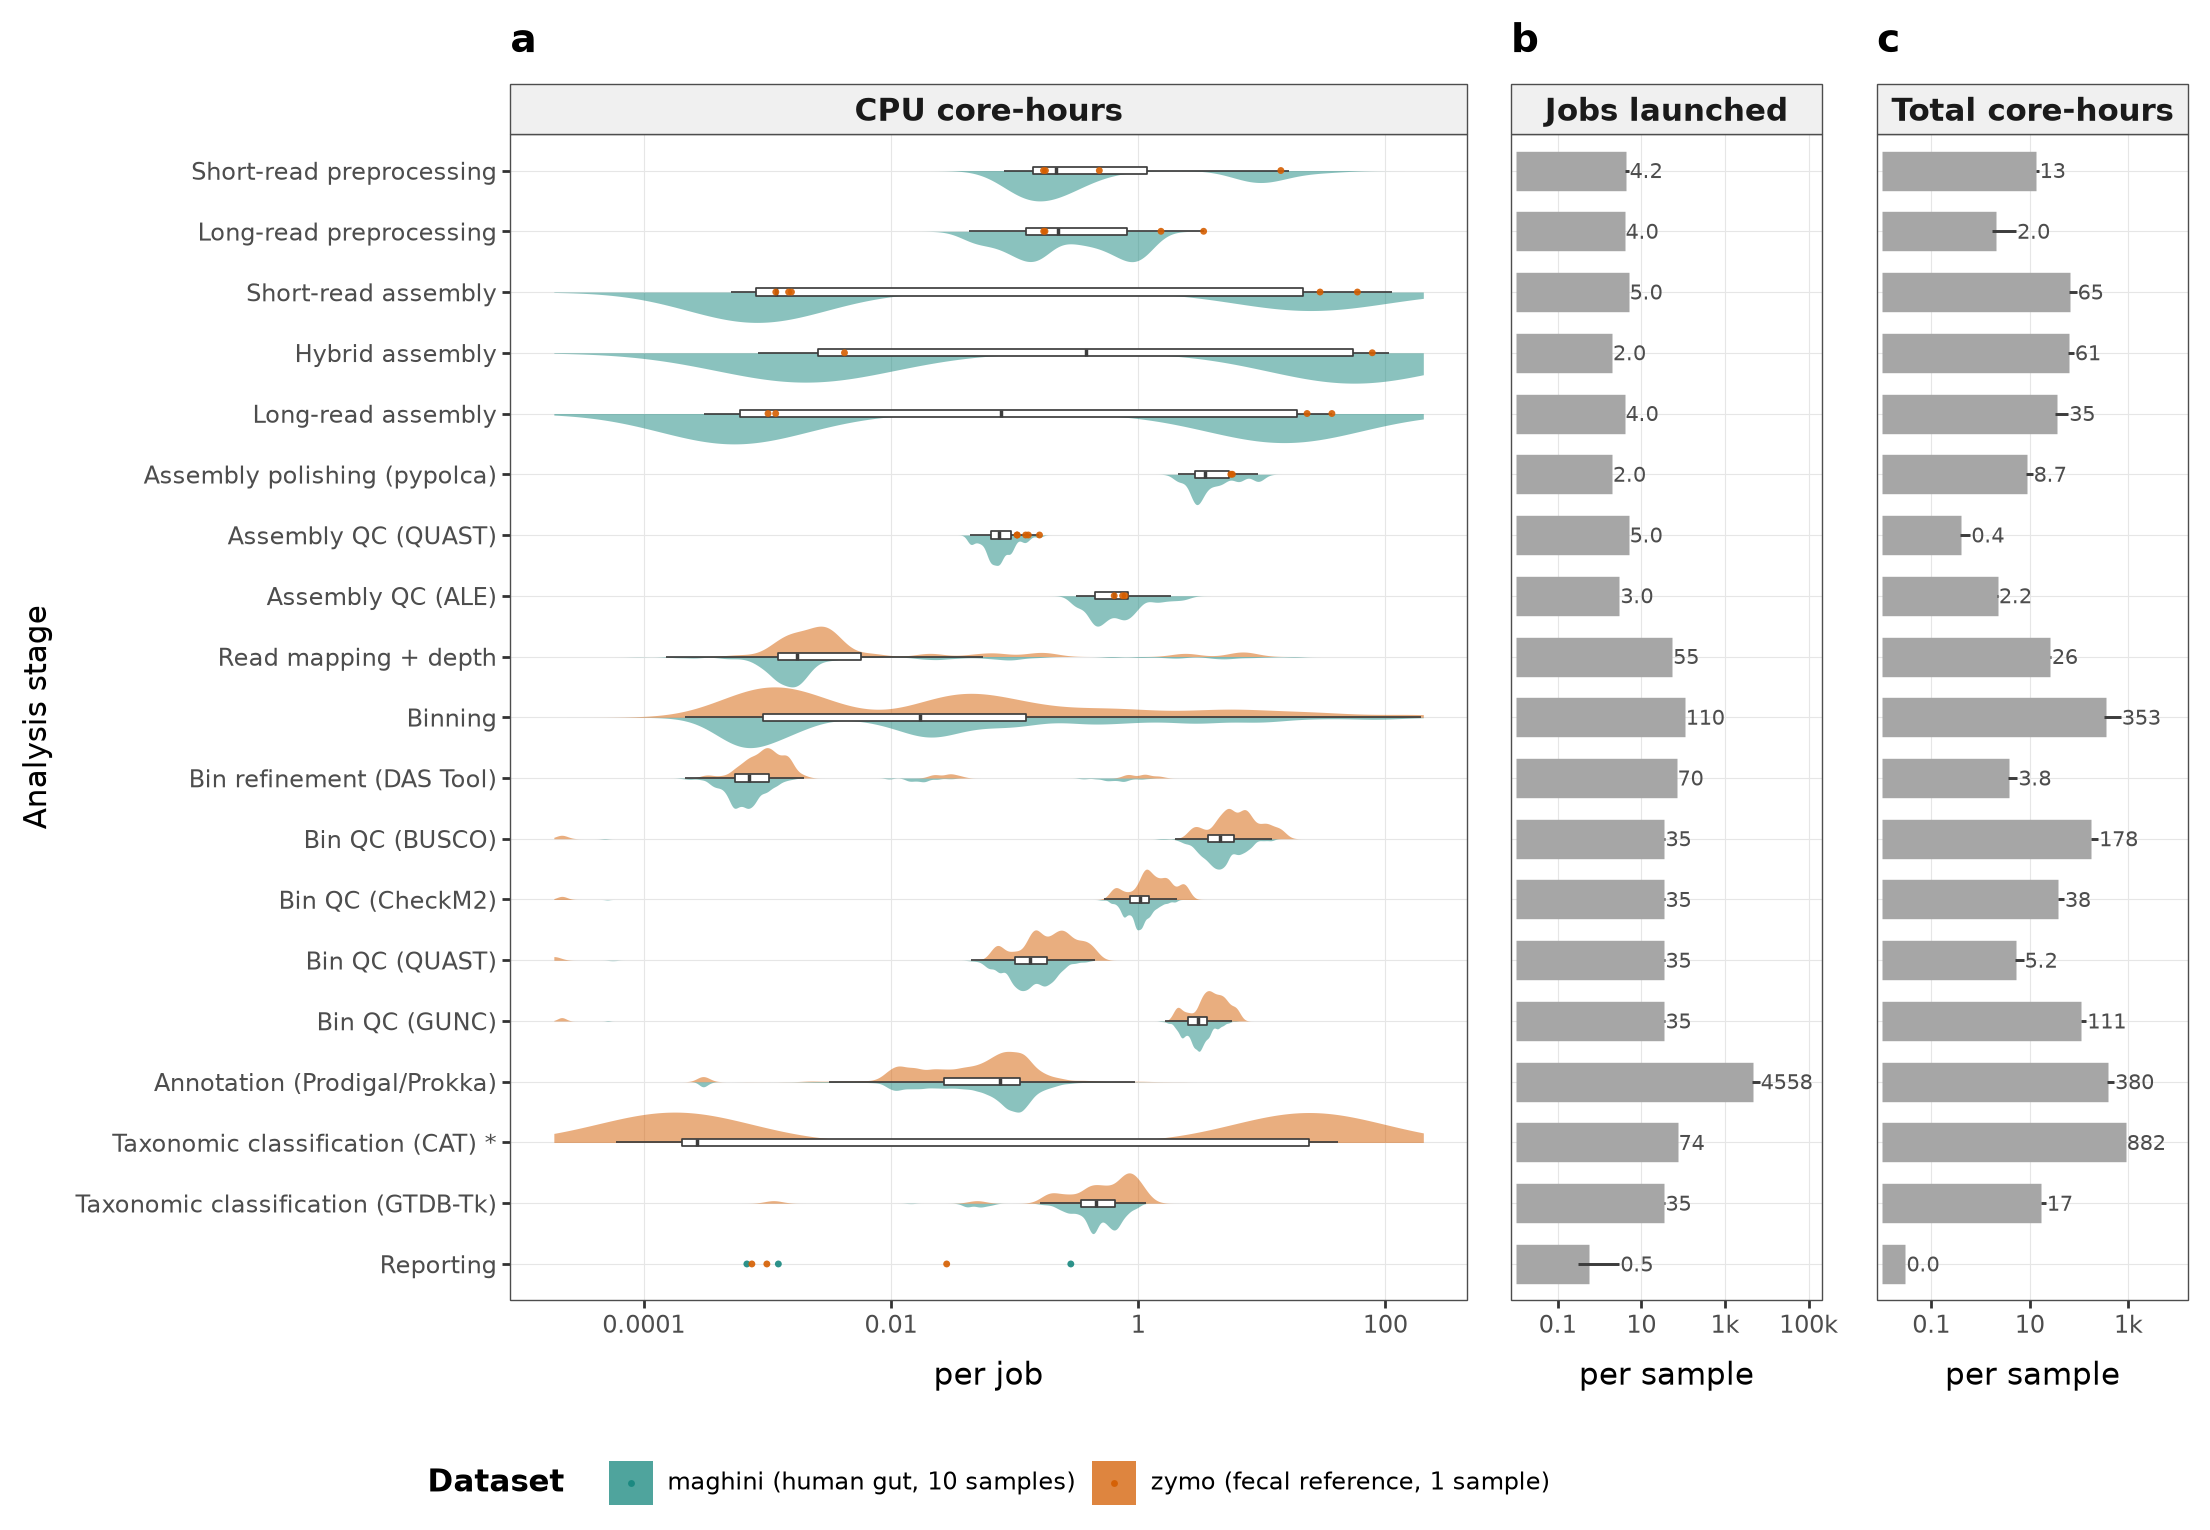

In [2]:
fg.fig_stage_compute(frames["budget"], frames["trace"])


### Figure 2. Storage per analysis stage

Data written (a) and data retained in the work directory (b) by each analysis stage, expressed per sample. Written data includes temporary files that may be removed before workflow completion. Points represent samples, box-plots show the distribution across both datasets when enough observations are available. Taxonomic classification (CAT), marked with an asterisk, ran on the ZymoBIOMICS data only, because of its high computational cost, so it contributes a single point. Assembly QC with QUAST and ALE is omitted, since both leave under 10 MB per sample on disk.


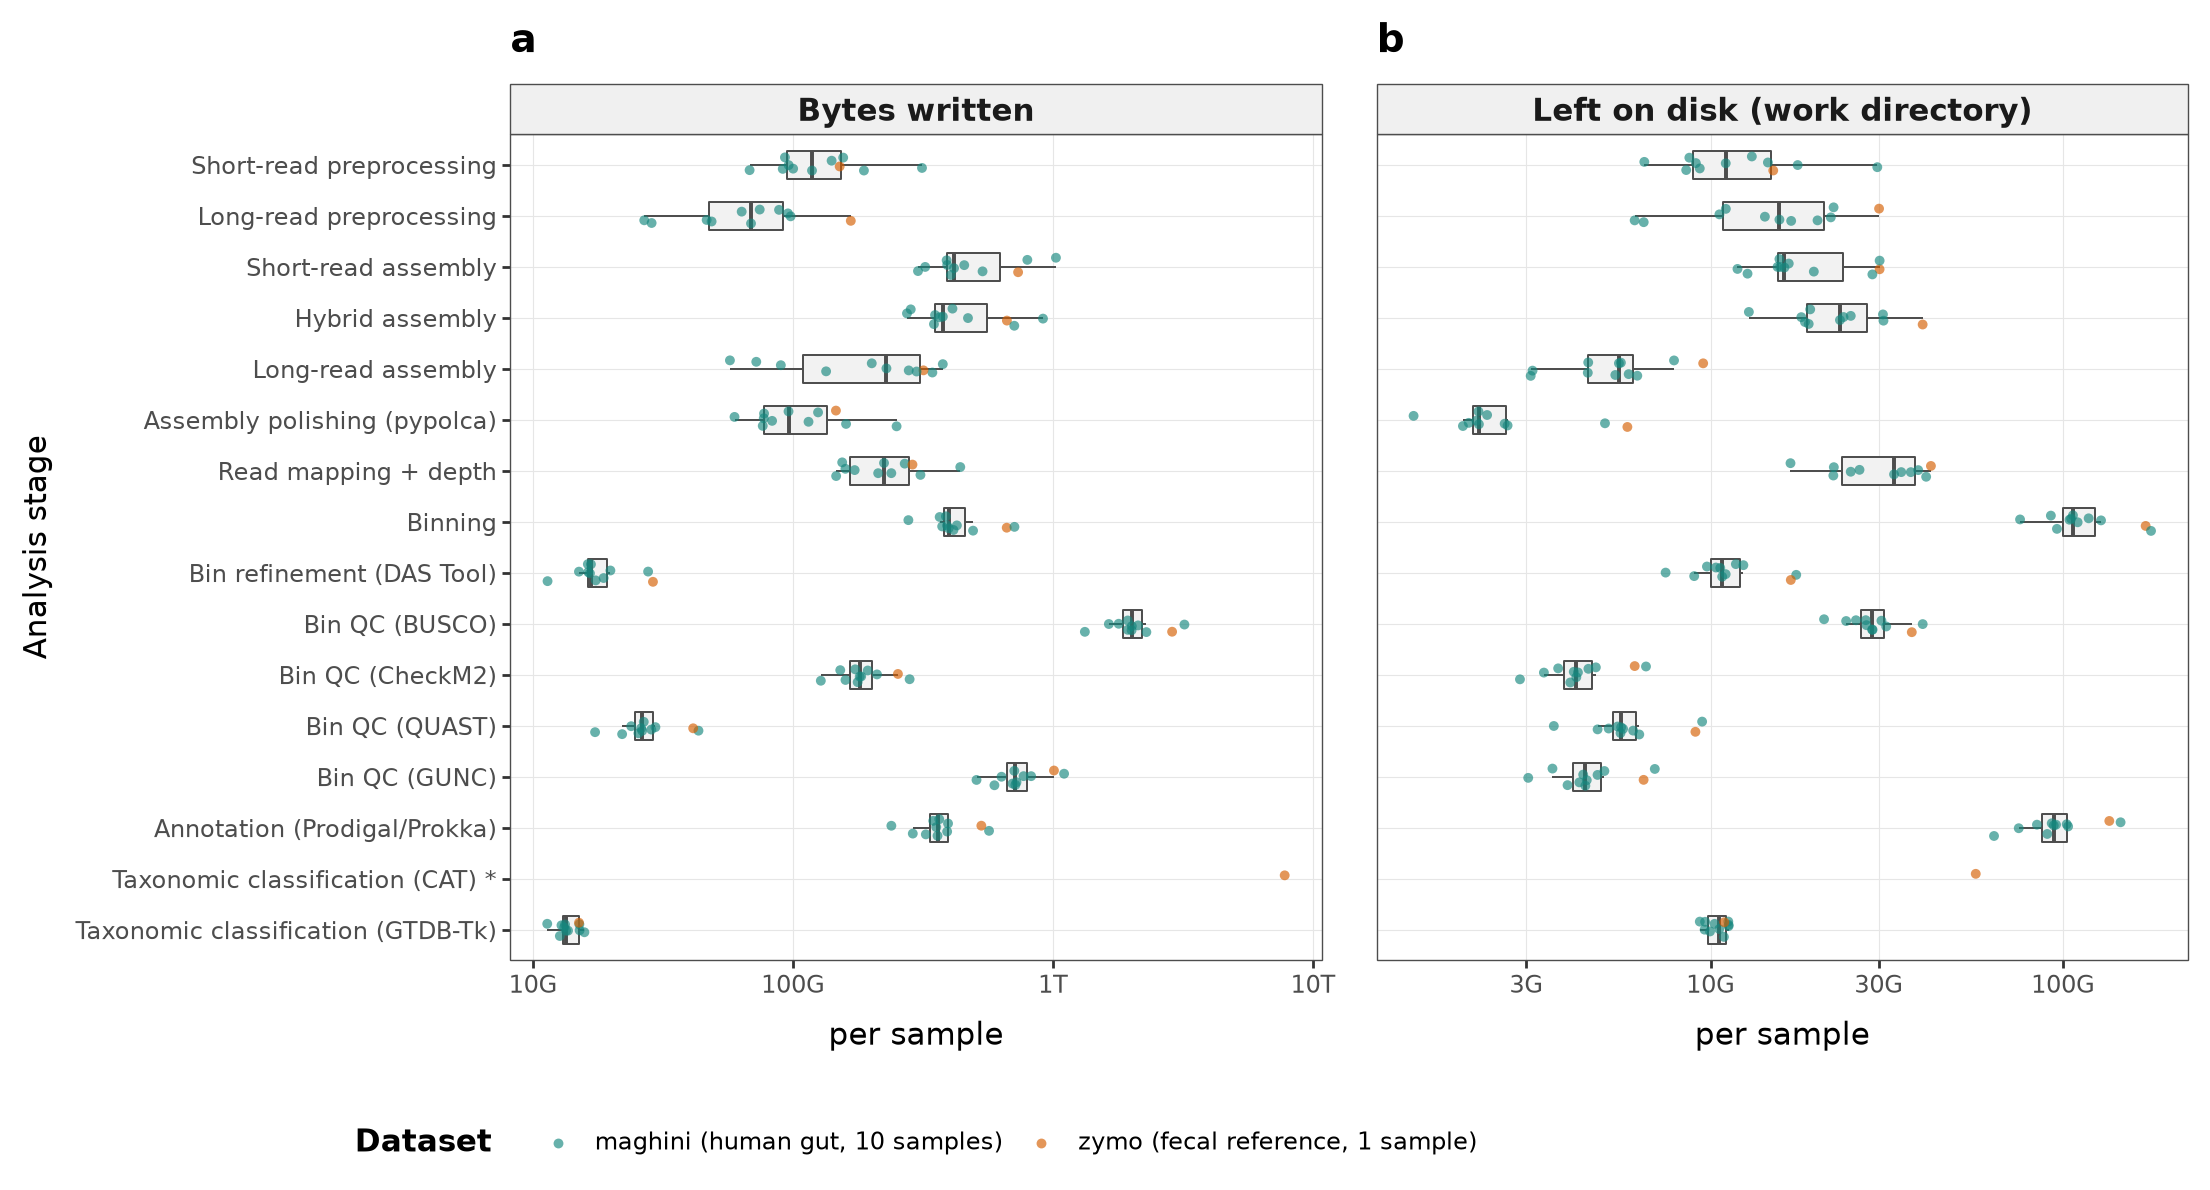

In [3]:
fg.fig_storage(frames["storage"], frames["storage_budget"])

### Figure 3. Resource footprint per assembler and binner

Peak memory, wall-clock time, and CPU core-hours for assemblers (top) and binners (bottom). Points represent individual assemblies or assembly–binner combinations, box-plots show the distribution across both datasets.


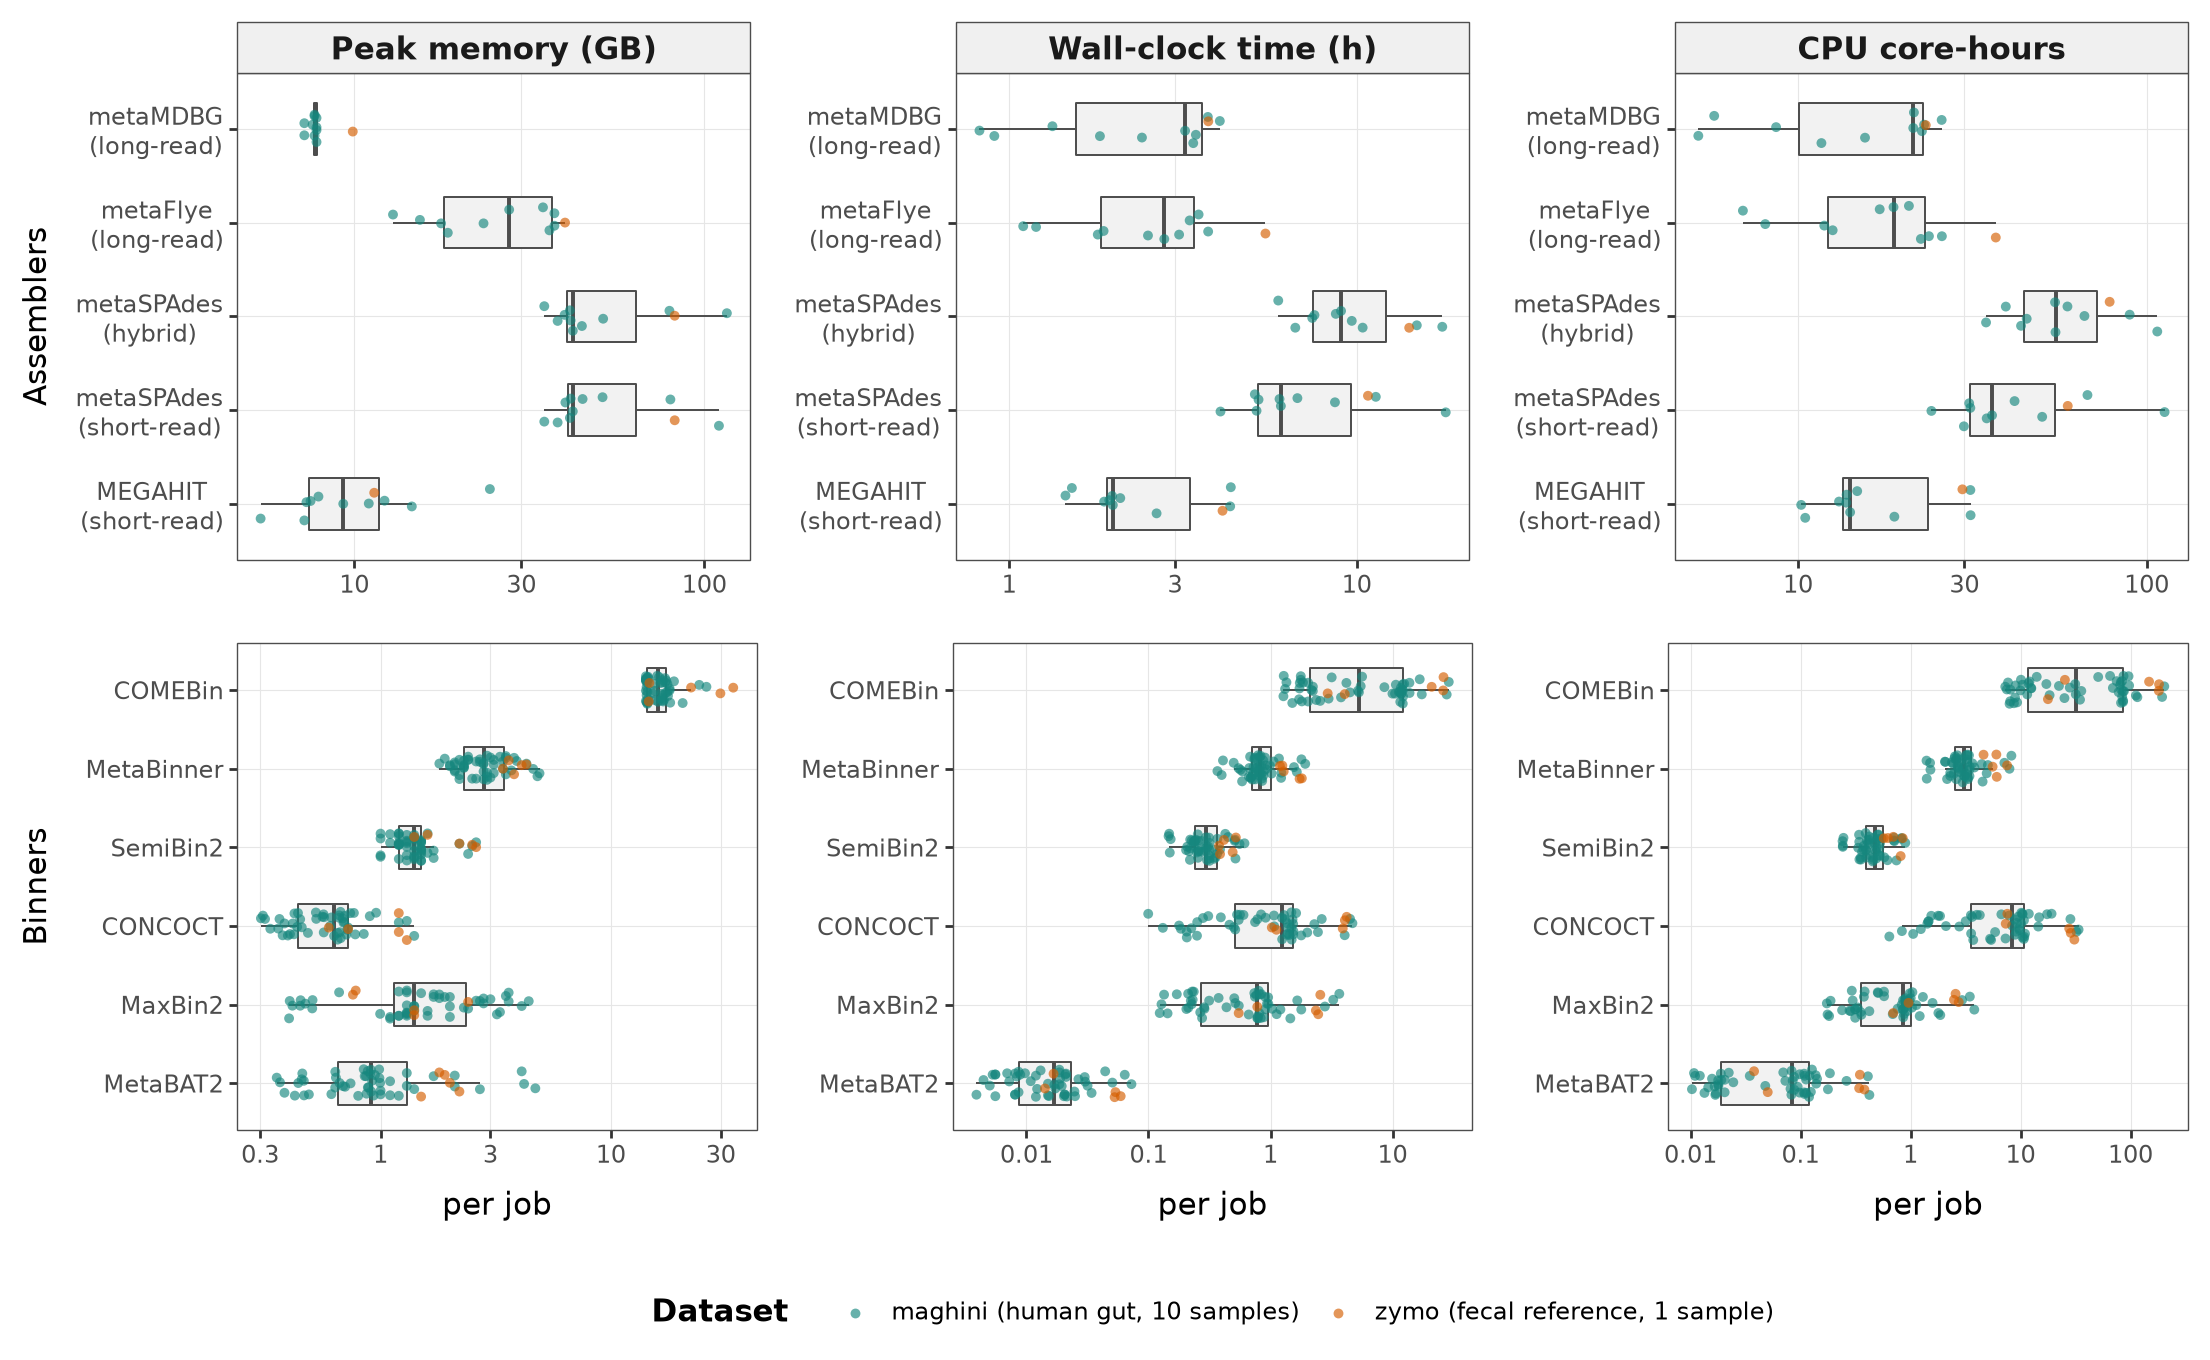

In [4]:
fg.fig_tool_footprint(frames["tasks"])

### Figure 4. Most resource-intensive processes per job

Processes with the highest median wall-clock time (a), peak memory (b), or work-directory size (c) per job. Each process is ranked separately by its median for each of the three resources, and processes are then ordered by their best (lowest) of those three ranks, with the sum of the three ranks breaking ties; the 15 highest-ranked are shown. Time and memory use logarithmic scales. The peak memory reported for GTDB-Tk (median 183 GB) overstates what it needs because its memory-mapped reference data is counted as resident in every job; it ran without failures on the 140 GB recommended by its developers.


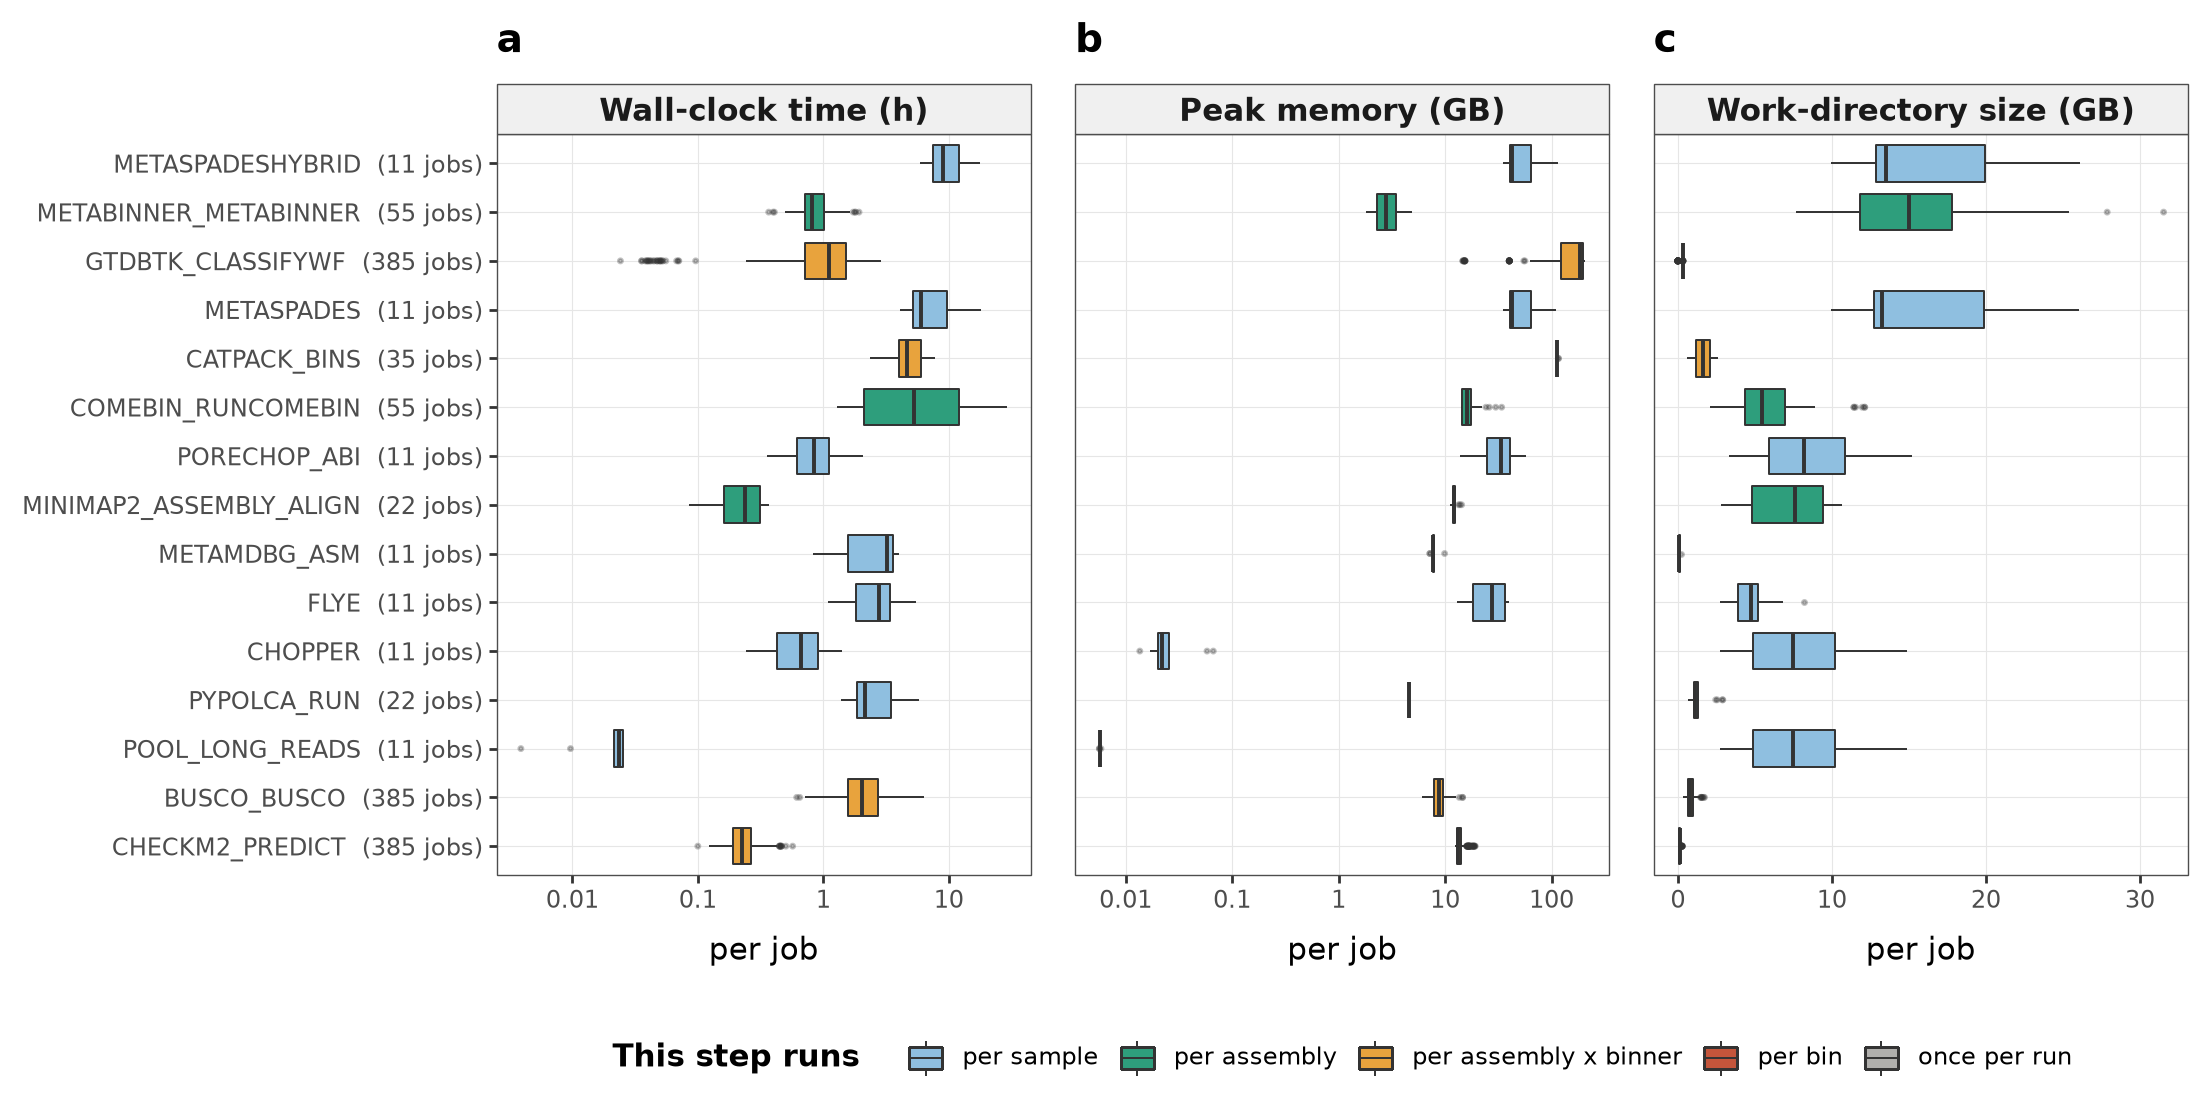

In [5]:
fg.fig_top_processes(frames["trace"])


### Figure 5. Assembler scaling with sequencing input

Assembler peak memory (top) and CPU core-hours (bottom) as a function of sequencing input. Input corresponds to short reads, long reads, or their sum according to the assembler. Points represent samples, grey bands show linear fits on log–log scales. Each panel is annotated with r, the Pearson correlation coefficient between the log-transformed variables, pooling both datasets.


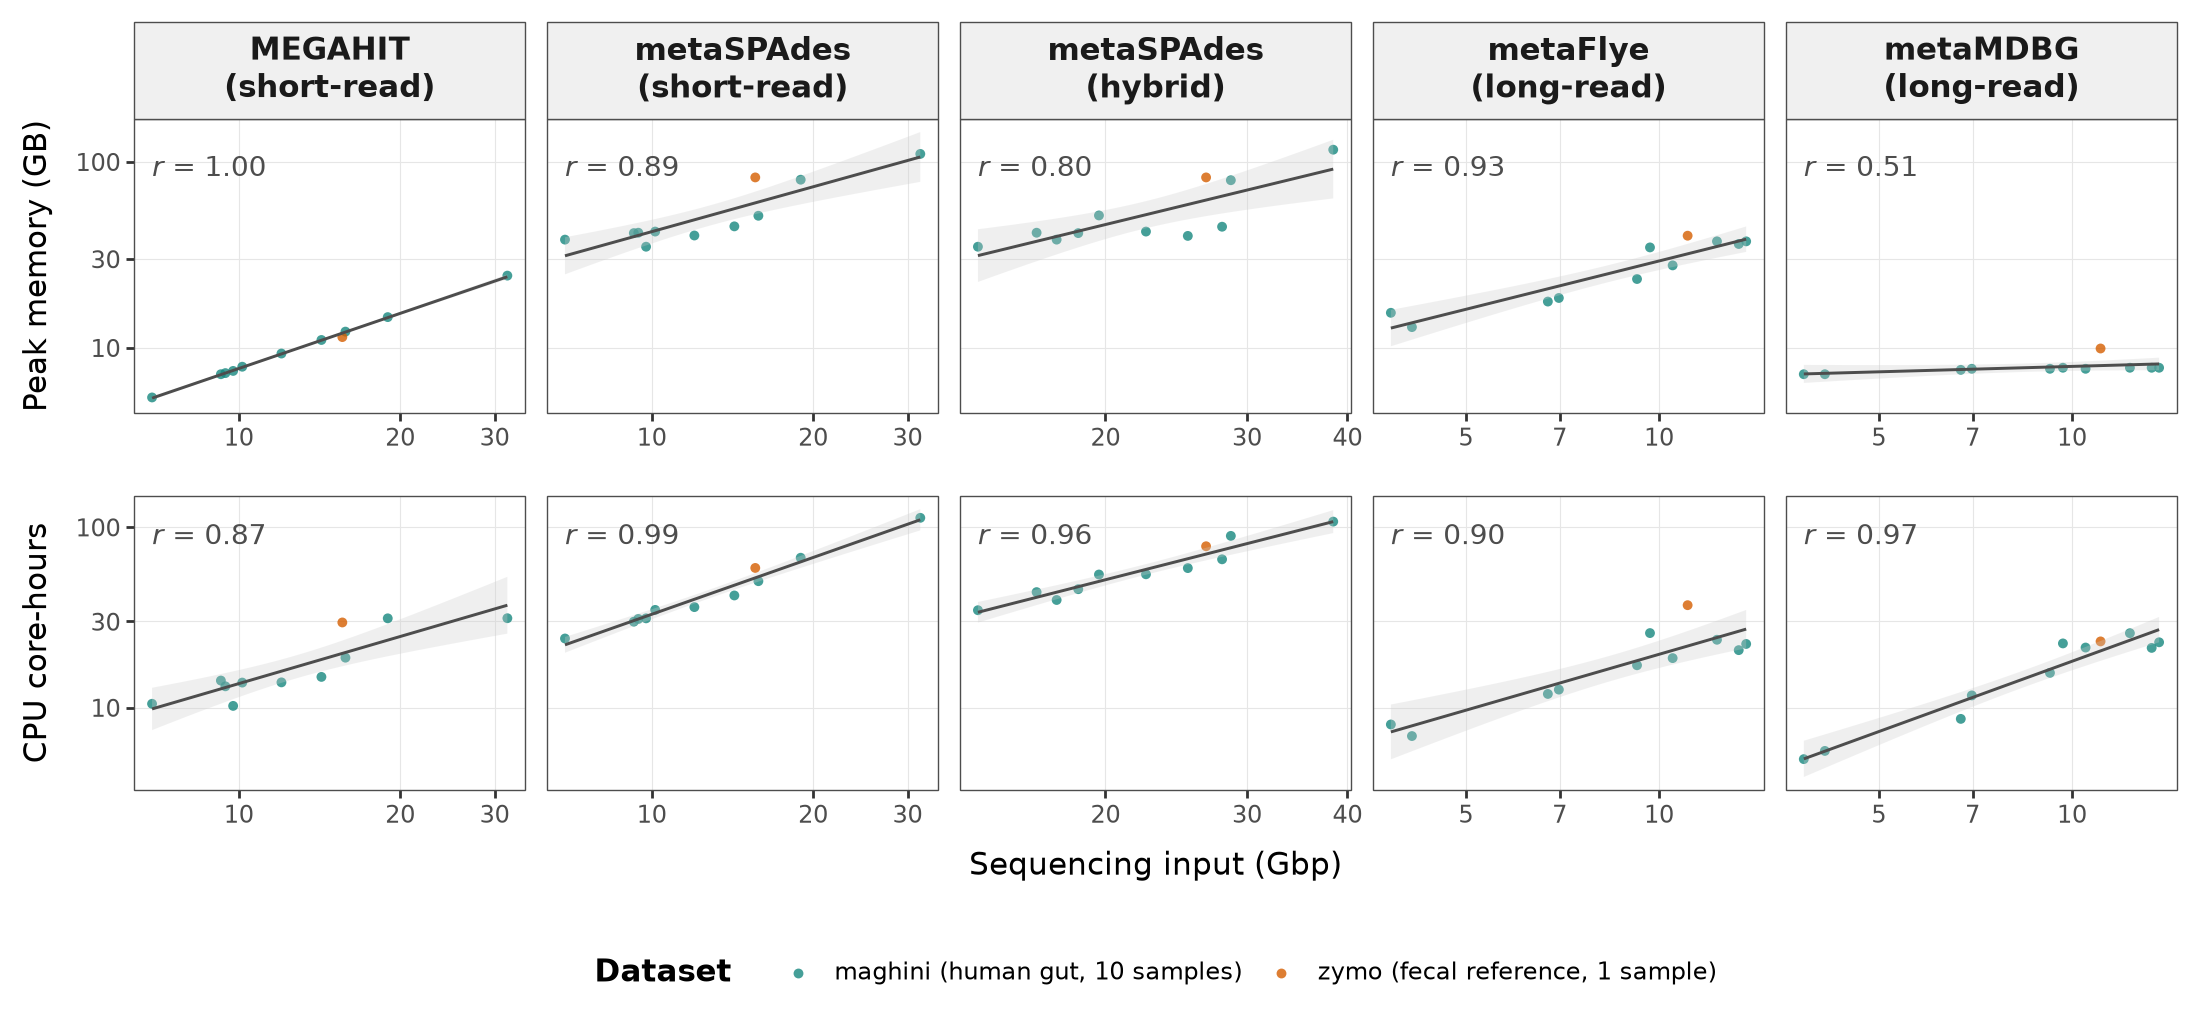

In [6]:
fg.fig_scaling_assemblers(frames["scaling"])


### Figure 6. Binner scaling with assembly size

Binner peak memory (top) and CPU core-hours (bottom) as a function of input assembly size. Points represent assembly–binner combinations, grey bands show linear fits on log–log scales. Each panel is annotated with r, the Pearson correlation coefficient between the log-transformed variables, pooling both datasets.


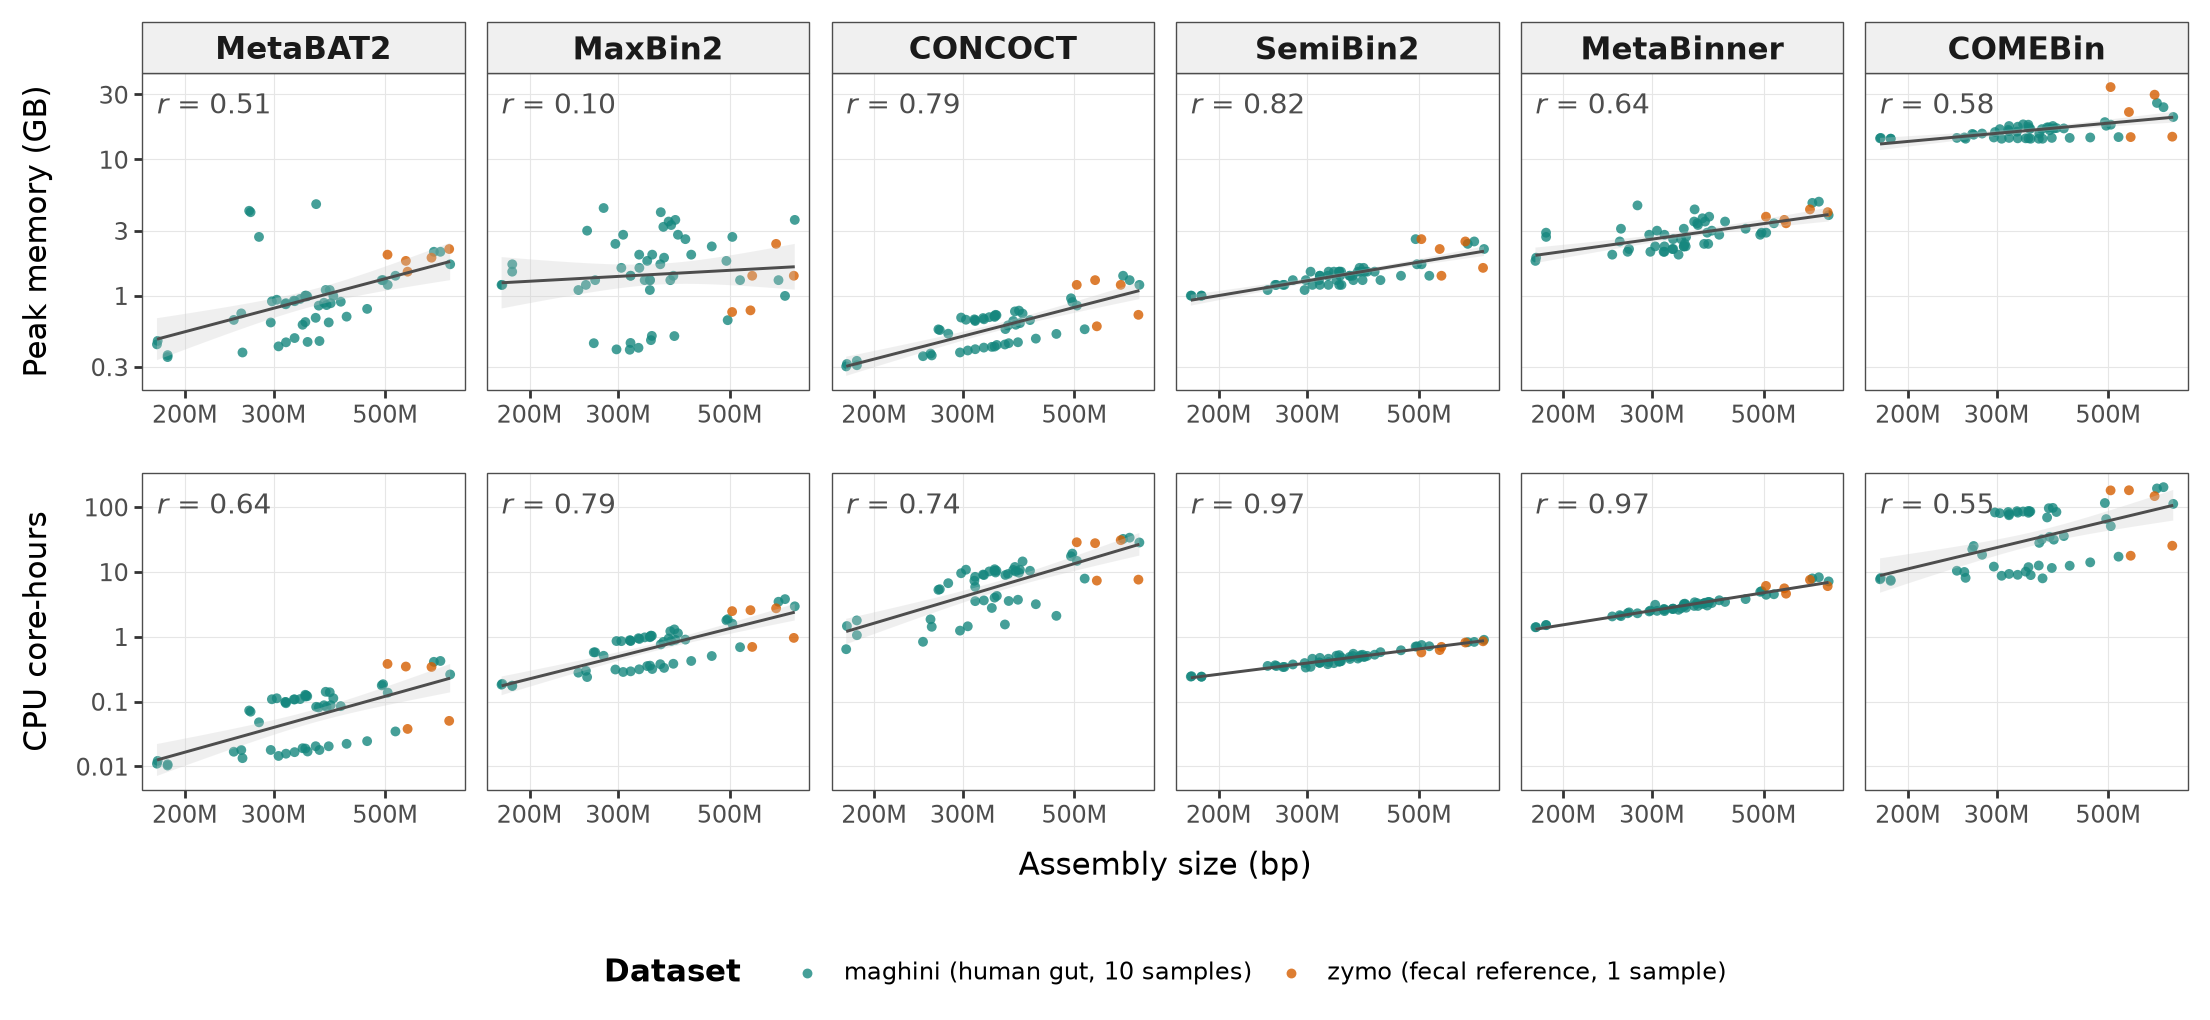

In [7]:
fg.fig_scaling_binners(frames["scaling"])

## Export


In [8]:
from mag_bench.build import build_all, save_all

save_all(build_all(DATA), out_dir="../figures", formats=["png", "pdf", "svg"])


../figures/S1_stage_compute.png  (2.3s)
../figures/S1_stage_compute.pdf  (2.1s)
../figures/S1_stage_compute.svg  (2.3s)
../figures/S2_storage.png  (0.8s)
../figures/S2_storage.pdf  (0.8s)
../figures/S2_storage.svg  (0.9s)
../figures/S3_tool_footprint.png  (1.6s)
../figures/S3_tool_footprint.pdf  (1.4s)
../figures/S3_tool_footprint.svg  (1.3s)
../figures/S4_top_processes.png  (2.6s)
../figures/S4_top_processes.pdf  (1.5s)
../figures/S4_top_processes.svg  (1.3s)
../figures/S5_scaling_assemblers.png  (1.0s)
../figures/S5_scaling_assemblers.pdf  (0.6s)
../figures/S5_scaling_assemblers.svg  (0.6s)
../figures/S6_scaling_binners.png  (1.1s)
../figures/S6_scaling_binners.pdf  (0.7s)
../figures/S6_scaling_binners.svg  (1.2s)


[PosixPath('../figures/S1_stage_compute.png'),
 PosixPath('../figures/S1_stage_compute.pdf'),
 PosixPath('../figures/S1_stage_compute.svg'),
 PosixPath('../figures/S2_storage.png'),
 PosixPath('../figures/S2_storage.pdf'),
 PosixPath('../figures/S2_storage.svg'),
 PosixPath('../figures/S3_tool_footprint.png'),
 PosixPath('../figures/S3_tool_footprint.pdf'),
 PosixPath('../figures/S3_tool_footprint.svg'),
 PosixPath('../figures/S4_top_processes.png'),
 PosixPath('../figures/S4_top_processes.pdf'),
 PosixPath('../figures/S4_top_processes.svg'),
 PosixPath('../figures/S5_scaling_assemblers.png'),
 PosixPath('../figures/S5_scaling_assemblers.pdf'),
 PosixPath('../figures/S5_scaling_assemblers.svg'),
 PosixPath('../figures/S6_scaling_binners.png'),
 PosixPath('../figures/S6_scaling_binners.pdf'),
 PosixPath('../figures/S6_scaling_binners.svg')]